# Reference based annotation of cells 


In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import scgeo as sg
from scipy import sparse


In [2]:

ref = sc.read_h5ad("data/hematlas_mouse_cross_shorten.h5ad")


In [3]:
ref

AnnData object with n_obs × n_vars = 73878 × 2910
    obs: 'celltype', 'stage', 'dataset', 'orig.ident', 'seurat_clusters'
    uns: 'X_name', 'celltype_colors', 'stage_colors'
    obsm: 'UMAP', 'X_umap'
    layers: 'logcounts'

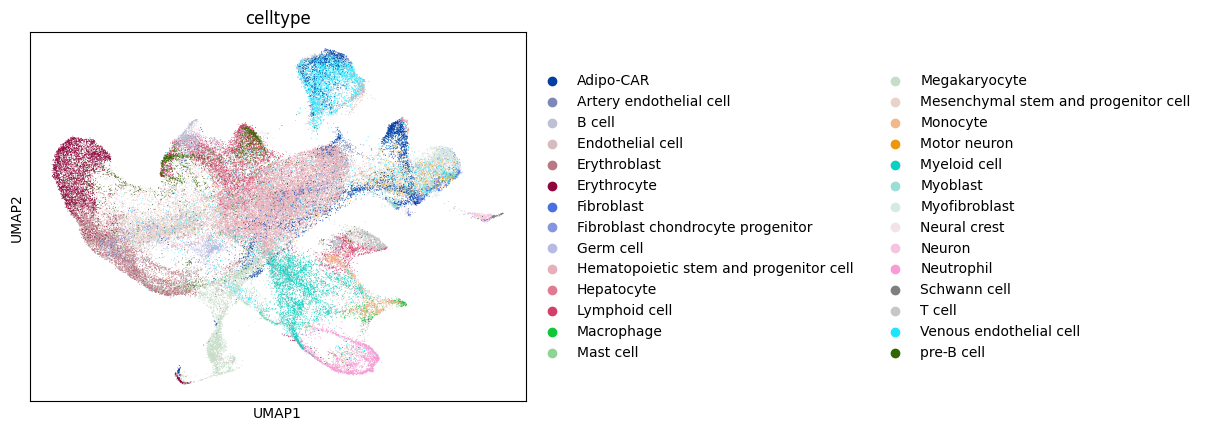

In [4]:
sc.pl.umap(ref, color='celltype')

In [5]:

adata=sc.read_h5ad("data/GSE280305_for_Ref.h5ad")

In [6]:

print(adata)

AnnData object with n_obs × n_vars = 31605 × 3000
    obs: 'timepoint', 'sample', 'gsm', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden_raw', 'scgeo_pred', 'scgeo_conf_entropy', 'scgeo_conf_margin', 'scgeo_conf', 'scgeo_ood', 'scgeo_reject', 'alignment_group', 'cluster_label_mannual'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std'
    uns: 'cluster_label_mannual_colors', 'hvg', 'leiden_raw', 'leiden_raw_colors', 'log1p', 'nbrs_raw', 'nbrs_scanorama', 'pca', 'rank_genes_groups', 'scgeo', 'timepoint_c

In [7]:
shared = ref.var_names.intersection(adata.var_names)
print("shared genes:", len(shared))
print(shared[:20].tolist())

shared genes: 2910
['Sox17', '1700034P13Rik', 'Prex2', 'Eya1', 'Trpa1', 'Kcnb2', 'Gm28376', 'Gm16070', 'Tfap2d', 'Kcnq5', '4931428L18Rik', 'Khdrbs2', 'Bend6', 'Neurl3', 'Zap70', 'Aff3', 'Lonrf2', 'Tbc1d8', 'Rfx8', 'Il1r2']


In [8]:
ref2 = sc.AnnData(
    X=ref[:, shared].X.copy(),
    obs=ref.obs.copy(),
    var=ref[:, shared].var.copy(),
)
ref2.obs["source"] = "reference"

qry2 = sc.AnnData(
    X=adata[:, shared].layers["matrix"].copy(),   # ← critical fix
    obs=adata.obs.copy(),
    var=adata[:, shared].var.copy(),
)
qry2.obs["source"] = "query"

qry2.obsm["X_umap_scanorama"] = adata.obsm["X_umap_scanorama"].copy()

In [9]:
combo = sc.concat(
    [ref2, qry2],
    label="dataset_source",
    keys=["reference", "query"],
    join="inner",
    merge="same",
    index_unique="-"
)

print(combo)
sc.pp.normalize_total(combo, target_sum=1e4)
sc.pp.log1p(combo)

# no HVG step
sc.pp.scale(combo, max_value=10)

sc.tl.pca(combo, n_comps=50, svd_solver="arpack")

ref_pca = combo[combo.obs["dataset_source"] == "reference"].copy()
qry_pca = combo[combo.obs["dataset_source"] == "query"].copy()

print(ref_pca)
print(qry_pca)

AnnData object with n_obs × n_vars = 105483 × 2910
    obs: 'source', 'dataset_source'


/usr/lib/python3.12/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


AnnData object with n_obs × n_vars = 73878 × 2910
    obs: 'source', 'dataset_source'
    var: 'mean', 'std'
    uns: 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
AnnData object with n_obs × n_vars = 31605 × 2910
    obs: 'source', 'dataset_source'
    var: 'mean', 'std'
    uns: 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'


In [10]:
# restore labels explicitly
ref_pca.obs["celltype"] = ref2.obs["celltype"].to_numpy()
ref_pca.obs["stage"] = ref2.obs["stage"].to_numpy()

In [11]:
X_ref = np.asarray(ref_pca.obsm["X_pca"], dtype=np.float32)

pool = sg.pp.build_reference_pool(
    X_ref,
    obs={
        "celltype": ref_pca.obs["celltype"].astype(str).to_numpy(),
        "stage": ref_pca.obs["stage"].astype(str).to_numpy(),
        "obs_names": ref_pca.obs_names.to_numpy(),
    },
    label_key="celltype",
    n_neighbors=30,
    metric="euclidean",
    random_state=0,
)

In [12]:
qry2 = qry2.copy()
qry2.obsm["X_refmap_pca"] = qry_pca.obsm["X_pca"].copy()
qry2.obsm["X_umap_scanorama"] = adata.obsm["X_umap_scanorama"].copy()

In [13]:
sg.tl.map_query_to_ref_pool(
    qry2,
    pool=pool,
    rep="X_refmap_pca",
    k=30,
    weight_method="inv",
    conf_method="entropy_margin",
    ood_method="distance",
    reject_conf=None,
    reject_ood=None,
    store_key="hematlas_celltype_map",
    pred_key="hematlas_pred",
    conf_key="hematlas_conf",
    conf_entropy_key="hematlas_conf_entropy",
    conf_margin_key="hematlas_conf_margin",
    ood_key="hematlas_ood",
    return_probs=False,
)

qry2.obs[[
    "hematlas_pred",
    "hematlas_conf",
    "hematlas_conf_entropy",
    "hematlas_conf_margin",
    "hematlas_ood",
]].head()

,hematlas_pred,hematlas_conf,hematlas_conf_entropy,hematlas_conf_margin,hematlas_ood
D8:GSM8594491:D8_count:AAAGCAACAGTCACTAx,Megakaryocyte,0.727711,0.850796,0.604626,0.446486
D8:GSM8594491:D8_count:AAAGATGAGGTGGGTTx,Megakaryocyte,0.897280,0.926893,0.867667,0.553095
D8:GSM8594491:D8_count:AAACGGGCAATGGAGCx,Endothelial cell,0.571718,0.743667,0.399769,0.320292
D8:GSM8594491:D8_count:AAACCTGAGTGTACCTx,Erythroblast,0.893322,0.924657,0.861988,0.580629
D8:GSM8594491:D8_count:AAACCTGAGACACTAAx,Megakaryocyte,0.684830,0.836867,0.532793,0.131871


In [14]:
qry2.obs["hematlas_flag"] = (
    (qry2.obs["hematlas_conf"] < qry2.obs["hematlas_conf"].quantile(0.15)) |
    (qry2.obs["hematlas_ood"] > qry2.obs["hematlas_ood"].quantile(0.95))
)

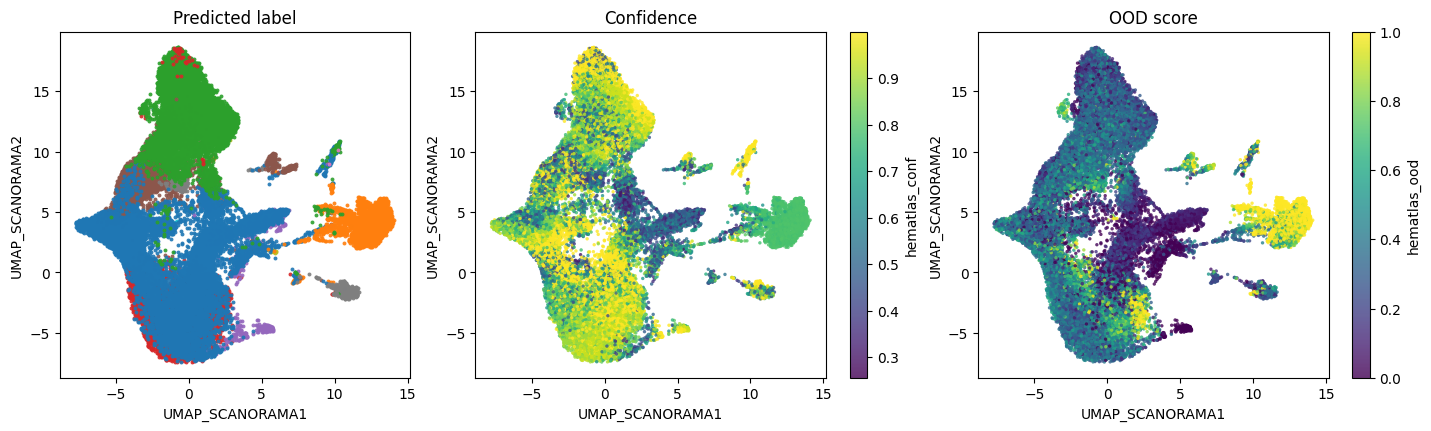

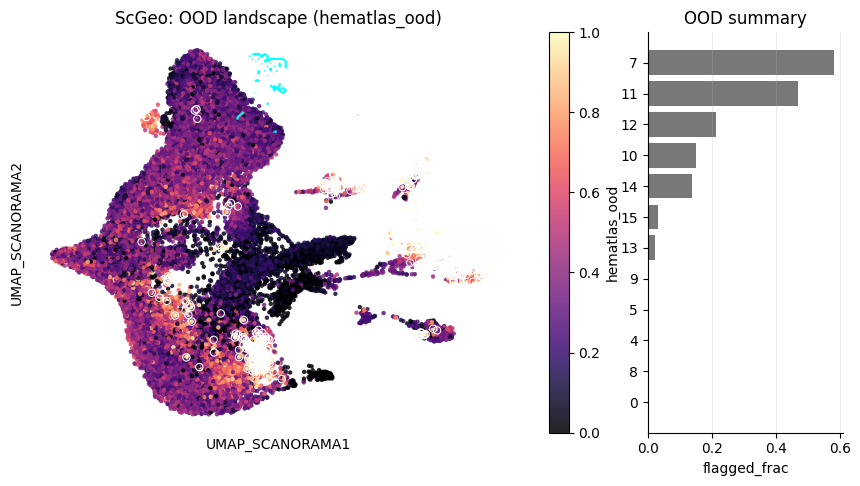

(<Figure size 1050x520 with 3 Axes>,
 (<Axes: title={'center': 'ScGeo: OOD landscape (hematlas_ood)'}, xlabel='UMAP_SCANORAMA1', ylabel='UMAP_SCANORAMA2'>,
  <Axes: title={'center': 'OOD summary'}, xlabel='flagged_frac'>))

In [15]:
sg.pl.mapping_qc_panel(
    qry2,
    pred_key="hematlas_pred",
    conf_key="hematlas_conf",
    ood_key="hematlas_ood",
    basis="umap_scanorama",
    show=True,
)

sg.pl.ood_landscape(
    qry2,
    ood_key="hematlas_ood",
    basis="umap_scanorama",
    threshold=qry2.obs["hematlas_ood"].quantile(0.95),
    groupby="leiden_raw",
    top_n_groups=12,
)

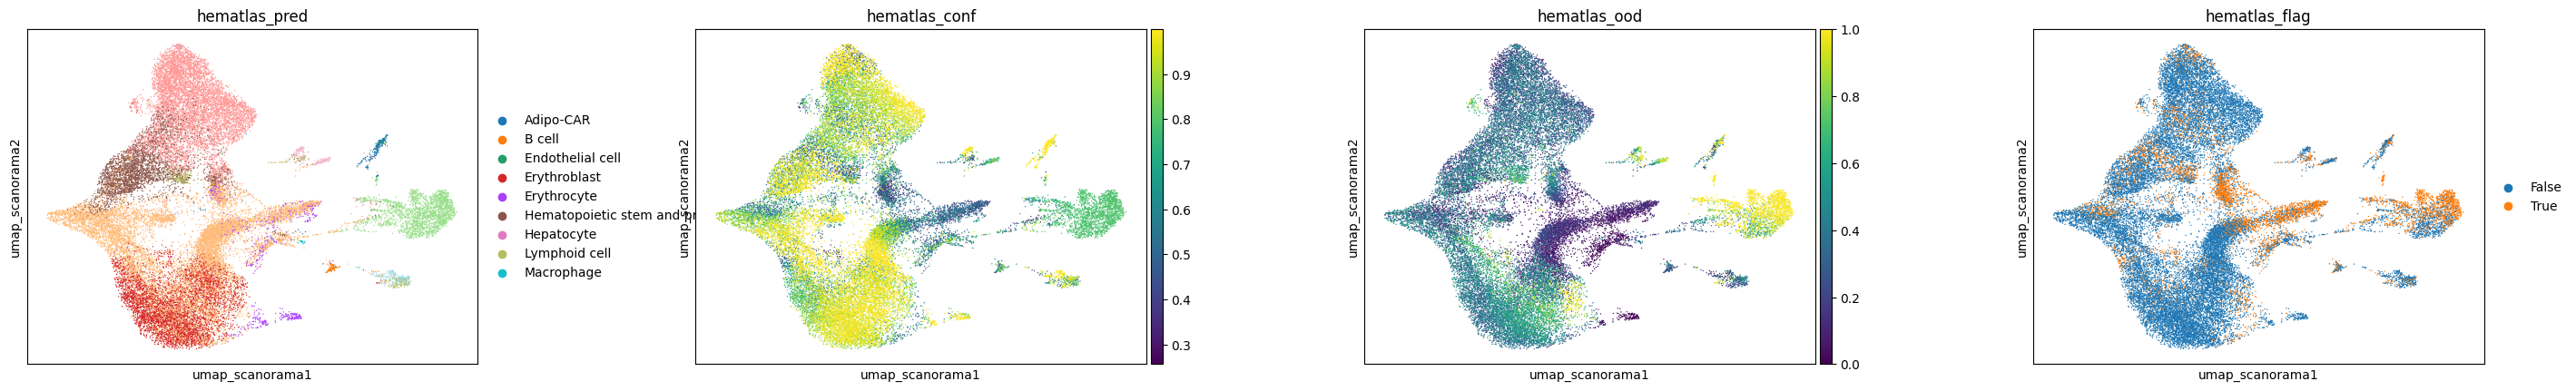

In [16]:
sc.pl.embedding(
    qry2,
    basis="umap_scanorama",
    color=["hematlas_pred", "hematlas_conf", "hematlas_ood", "hematlas_flag"],
    wspace=0.35,
)

In [17]:
cluster_comp = pd.crosstab(
    qry2.obs["leiden_raw"].astype(str),
    qry2.obs["hematlas_pred"].astype(str),
    normalize="index"
)

cluster_dashboard = pd.DataFrame(index=cluster_comp.index)
cluster_dashboard["n_cells"] = qry2.obs.groupby("leiden_raw").size().reindex(cluster_dashboard.index).values
cluster_dashboard["dominant_label"] = cluster_comp.idxmax(axis=1)
cluster_dashboard["dominant_frac"] = cluster_comp.max(axis=1)
cluster_dashboard["mean_conf"] = qry2.obs.groupby("leiden_raw")["hematlas_conf"].mean().reindex(cluster_dashboard.index).values
cluster_dashboard["mean_ood"] = qry2.obs.groupby("leiden_raw")["hematlas_ood"].mean().reindex(cluster_dashboard.index).values
cluster_dashboard["flag_frac"] = qry2.obs.groupby("leiden_raw")["hematlas_flag"].mean().reindex(cluster_dashboard.index).values

cluster_dashboard.sort_values(["mean_ood", "flag_frac"], ascending=[False, False]).head(20)

/tmp/ipykernel_1119/4151282986.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_dashboard["n_cells"] = qry2.obs.groupby("leiden_raw").size().reindex(cluster_dashboard.index).values
/tmp/ipykernel_1119/4151282986.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_dashboard["mean_conf"] = qry2.obs.groupby("leiden_raw")["hematlas_conf"].mean().reindex(cluster_dashboard.index).values
/tmp/ipykernel_1119/4151282986.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observ

,n_cells,dominant_label,dominant_frac,mean_conf,mean_ood,flag_frac
leiden_raw,,,,,,
7,1802,Monocyte,1.000000,0.785513,0.891109,0.583796
11,507,Monocyte,0.773176,0.688708,0.756150,0.607495
14,324,T cell,0.722222,0.725634,0.688261,0.305556
15,287,Erythroblast,0.449477,0.656654,0.683466,0.348432
10,729,Megakaryocyte,0.395062,0.853506,0.496187,0.224966
12,418,Adipo-CAR,0.418660,0.825051,0.473365,0.356459
0,5212,Megakaryocyte,0.587299,0.920692,0.469226,0.035879
6,1949,Erythroblast,0.834787,0.809666,0.338025,0.071832
2,3713,Hematopoietic stem and progenitor cell,0.670617,0.773078,0.331517,0.193644


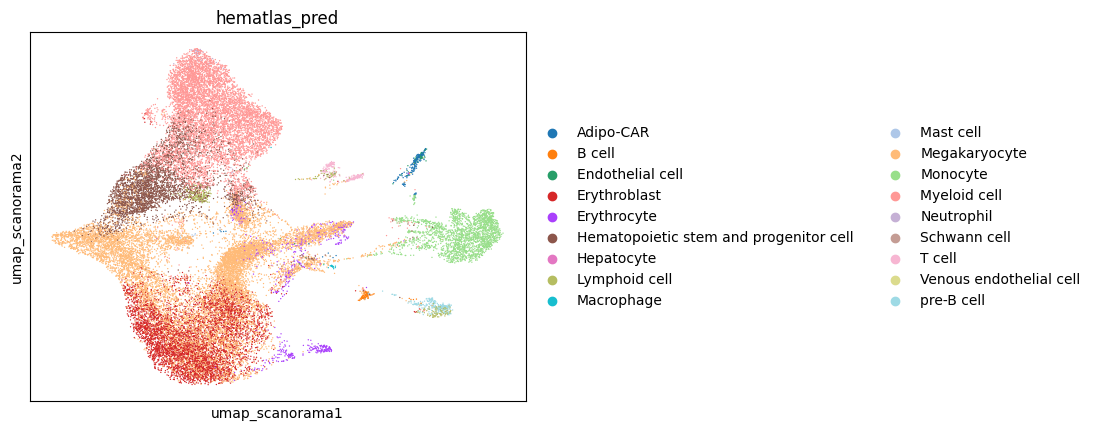

In [18]:
sc.pl.embedding(
    qry2,
    basis="umap_scanorama",
    color="hematlas_pred",
    wspace=0.35,
)

In [19]:
print(adata)
print(qry2)

AnnData object with n_obs × n_vars = 31605 × 3000
    obs: 'timepoint', 'sample', 'gsm', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden_raw', 'scgeo_pred', 'scgeo_conf_entropy', 'scgeo_conf_margin', 'scgeo_conf', 'scgeo_ood', 'scgeo_reject', 'alignment_group', 'cluster_label_mannual'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std'
    uns: 'cluster_label_mannual_colors', 'hvg', 'leiden_raw', 'leiden_raw_colors', 'log1p', 'nbrs_raw', 'nbrs_scanorama', 'pca', 'rank_genes_groups', 'scgeo', 'timepoint_c

In [20]:
print(adata.n_obs, qry2.n_obs)
print(adata.obs_names.equals(qry2.obs_names))
print((adata.obs_names == qry2.obs_names).all())
print(len(adata.obs_names.intersection(qry2.obs_names)))

31605 31605
True
True
31605


In [21]:
cols_to_transfer = [
    "hematlas_pred",
    "hematlas_conf_entropy",
    "hematlas_conf_margin",
    "hematlas_conf",
    "hematlas_ood",
    "hematlas_flag",
]

for col in cols_to_transfer:
    adata.obs[col] = qry2.obs.loc[adata.obs_names, col]

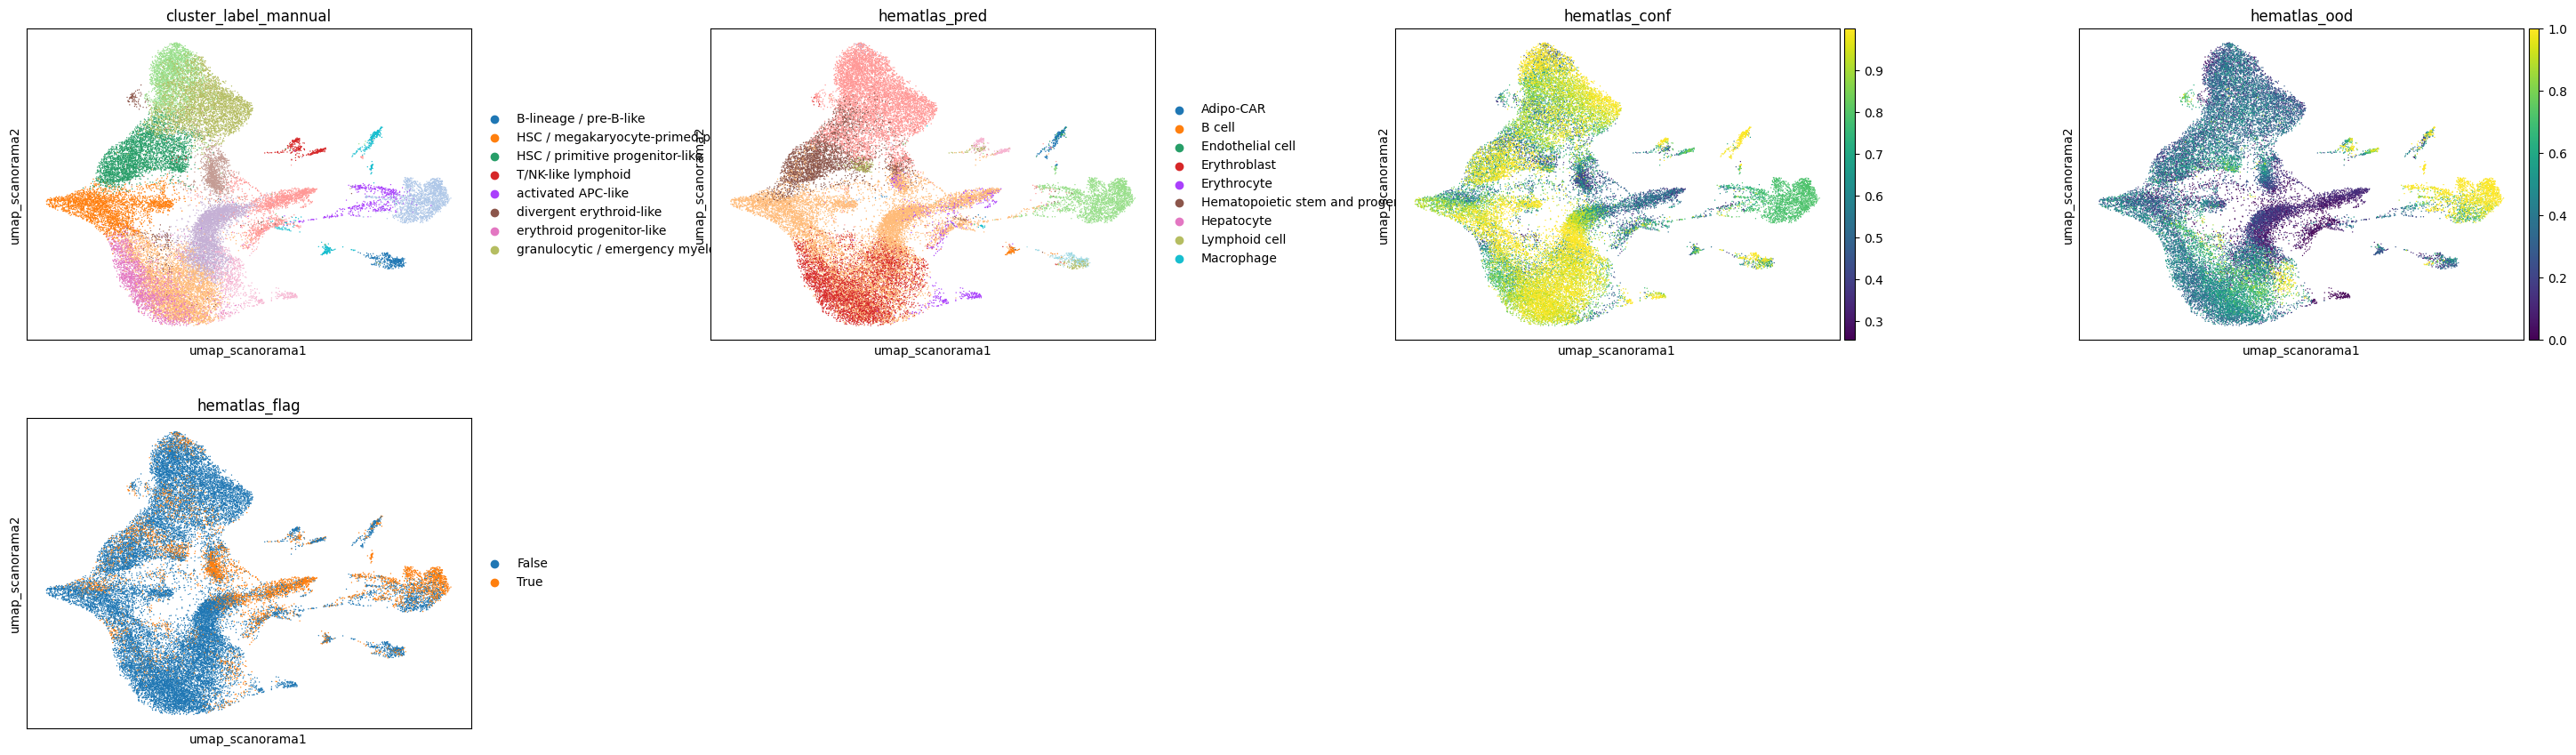

In [22]:
sc.pl.embedding(
    adata,
    basis="umap_scanorama",
    color=[
        "cluster_label_mannual",
        "hematlas_pred",
        "hematlas_conf",
        "hematlas_ood",
        "hematlas_flag",
    ],
    wspace=0.4,
)

In [23]:
import pandas as pd

cmp = pd.crosstab(
    adata.obs["cluster_label_mannual"],
    adata.obs["hematlas_pred"],
    normalize="index"
)

cmp

hematlas_pred,Adipo-CAR,B cell,Endothelial cell,Erythroblast,Erythrocyte,Hematopoietic stem and progenitor cell,Hepatocyte,Lymphoid cell,Macrophage,Mast cell,Megakaryocyte,Monocyte,Myeloid cell,Neutrophil,Schwann cell,T cell,Venous endothelial cell,pre-B cell
cluster_label_mannual,,,,,,,,,,,,,,,,,,
B-lineage / pre-B-like,0.000000,0.013477,0.000000,0.013477,0.002695,0.002695,0.000000,0.274933,0.000000,0.000000,0.029650,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.663073
HSC / megakaryocyte-primed progenitor-like,0.000000,0.000000,0.000000,0.002254,0.000322,0.062158,0.000000,0.000322,0.000000,0.003865,0.924960,0.000000,0.006119,0.000000,0.000000,0.000000,0.000000,0.000000
HSC / primitive progenitor-like,0.000000,0.000000,0.000000,0.000000,0.000000,0.670617,0.000000,0.046054,0.000000,0.000000,0.041745,0.000000,0.241584,0.000000,0.000000,0.000000,0.000000,0.000000
T/NK-like lymphoid,0.003086,0.000000,0.000000,0.003086,0.003086,0.033951,0.000000,0.169753,0.000000,0.000000,0.055556,0.003086,0.006173,0.000000,0.000000,0.722222,0.000000,0.000000
activated APC-like,0.000000,0.000000,0.000000,0.001972,0.001972,0.021696,0.000000,0.001972,0.000000,0.000000,0.155819,0.773176,0.043393,0.000000,0.000000,0.000000,0.000000,0.000000
divergent erythroid-like,0.000000,0.000000,0.000000,0.449477,0.003484,0.080139,0.000000,0.000000,0.000000,0.000000,0.114983,0.000000,0.351916,0.000000,0.000000,0.000000,0.000000,0.000000
erythroid progenitor-like,0.000000,0.000000,0.000000,0.834787,0.003079,0.000000,0.000000,0.000000,0.000000,0.000000,0.162134,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
granulocytic / emergency myeloid,0.000000,0.000000,0.000000,0.000000,0.000000,0.065466,0.000000,0.000000,0.000286,0.000000,0.000286,0.001429,0.932247,0.000286,0.000000,0.000000,0.000000,0.000000
macrophage-like / remodeling myeloid,0.418660,0.196172,0.112440,0.004785,0.009569,0.011962,0.002392,0.000000,0.000000,0.002392,0.133971,0.064593,0.014354,0.000000,0.000000,0.000000,0.004785,0.023923


In [24]:
cmp_counts = pd.crosstab(
    adata.obs["cluster_label_mannual"],
    adata.obs["hematlas_pred"]
)

cmp_counts

hematlas_pred,Adipo-CAR,B cell,Endothelial cell,Erythroblast,Erythrocyte,Hematopoietic stem and progenitor cell,Hepatocyte,Lymphoid cell,Macrophage,Mast cell,Megakaryocyte,Monocyte,Myeloid cell,Neutrophil,Schwann cell,T cell,Venous endothelial cell,pre-B cell
cluster_label_mannual,,,,,,,,,,,,,,,,,,
B-lineage / pre-B-like,0,5,0,5,1,1,0,102,0,0,11,0,0,0,0,0,0,246
HSC / megakaryocyte-primed progenitor-like,0,0,0,7,1,193,0,1,0,12,2872,0,19,0,0,0,0,0
HSC / primitive progenitor-like,0,0,0,0,0,2490,0,171,0,0,155,0,897,0,0,0,0,0
T/NK-like lymphoid,1,0,0,1,1,11,0,55,0,0,18,1,2,0,0,234,0,0
activated APC-like,0,0,0,1,1,11,0,1,0,0,79,392,22,0,0,0,0,0
divergent erythroid-like,0,0,0,129,1,23,0,0,0,0,33,0,101,0,0,0,0,0
erythroid progenitor-like,0,0,0,1627,6,0,0,0,0,0,316,0,0,0,0,0,0,0
granulocytic / emergency myeloid,0,0,0,0,0,229,0,0,1,0,1,5,3261,1,0,0,0,0
macrophage-like / remodeling myeloid,175,82,47,2,4,5,1,0,0,1,56,27,6,0,0,0,2,10


In [25]:
summary = (
    adata.obs
    .groupby("cluster_label_mannual")
    .agg(
        n_cells=("hematlas_pred", "size"),
        top_ref=("hematlas_pred", lambda x: x.value_counts().index[0]),
        top_ref_frac=("hematlas_pred", lambda x: x.value_counts(normalize=True).iloc[0]),
        mean_conf=("hematlas_conf", "mean"),
        mean_ood=("hematlas_ood", "mean"),
        flag_frac=("hematlas_flag", "mean"),
    )
    .sort_values("mean_ood", ascending=False)
)

summary

/tmp/ipykernel_1119/2665823707.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("cluster_label_mannual")


,n_cells,top_ref,top_ref_frac,mean_conf,mean_ood,flag_frac
cluster_label_mannual,,,,,,
stable APC-like,1802,Monocyte,1.000000,0.785513,0.891109,0.583796
activated APC-like,507,Monocyte,0.773176,0.688708,0.756150,0.607495
T/NK-like lymphoid,324,T cell,0.722222,0.725634,0.688261,0.305556
divergent erythroid-like,287,Erythroblast,0.449477,0.656654,0.683466,0.348432
transitional erythroid,729,Megakaryocyte,0.395062,0.853506,0.496187,0.224966
macrophage-like / remodeling myeloid,418,Adipo-CAR,0.418660,0.825051,0.473365,0.356459
stable erythroid,5212,Megakaryocyte,0.587299,0.920692,0.469226,0.035879
erythroid progenitor-like,1949,Erythroblast,0.834787,0.809666,0.338025,0.071832
HSC / primitive progenitor-like,3713,Hematopoietic stem and progenitor cell,0.670617,0.773078,0.331517,0.193644


In [26]:
adata.write_h5ad("data/GSE280305_with_Ref.h5ad")